In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 4000
maxForce = 1e-20

In [3]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sum(d**2)

In [4]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = 2 * lam * d
    g1x = pref * d[1] + lambd[0]
    g1y = -pref * (r1[0] + r2[0]) + lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

<Figure size 640x480 with 0 Axes>

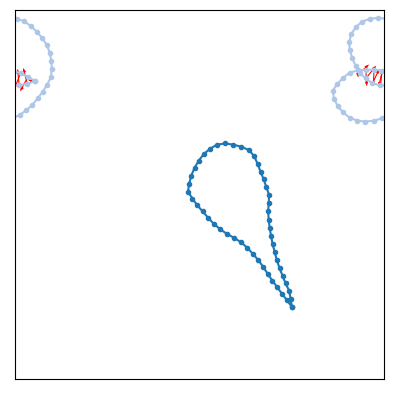

In [6]:
lam = 0.01
pref = 1
numPolygons = 2
n = 50
i = 4
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 5, phi = 0.1)
#m.setPositions(np.load("negativeEnergyTest.npy"))
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# A negative energy is bad news for lam = 0
# Let's look at it closely:
fig, ax = plt.subplots()
#artists = m.draw(ax = ax, forces = force, arrowColor = 'b')
# Okay, next we consider applying forces to the x direction of each
# shape in opposing directions
numVertices = m.getNumVertices()
addedForce = np.ones(numVertices * 2) * maxForce
addedForce[numVertices:] *= -1
addedForce[::2] = 0

startPos = m.getPositions()
#m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps, addedForce = addedForce, progress = 10)
#m.initializeNeighborCells()
#m.updateNeighborCells()
#m.updateNeighbors(0)
#overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
#force += addedForce
#force0 = m.getConstrainedForce(force)
#positions0 = m.getPositions()
artists = m.draw(ax = ax, forces = force)

In [7]:
pref = 1
lam = 0.1
allPos = []
allForce = []
for i in range(maxSteps):
    if (i % 100 == 0):
        print(i)
    startPos = m.getPositions()
    m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, dt = 5e-4, maxSteps = 1)
    m.initializeNeighborCells()
    m.updateNeighborCells()
    m.updateNeighbors(0)
    _, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
    overlapArea, _ = m.functional(h = h, g12 = g12, lam = 0, pref = 1)
    allPos.append(m.getPositions())
    allForce.append(m.getConstrainedForce(force))

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900


In [8]:
# This tiny force was enough to pull it apart.
# Let's ramp up lambda and ramp down the force 
print(overlapArea, max(abs(force)))

0.00017847339997296638 0.24544419647592705


In [9]:
def update(frame):
    ax.clear()
    m.setPositions(allPos[frame])
    return m.draw(ax = ax, forces = allForce[frame])

In [10]:
ani = FuncAnimation(fig, update, frames = len(allPos), interval = 50, blit = True)
ani.save("pullingHardly.mp4", fps = 20)

In [ ]:
# testing positions
np.save("pullingLightlyPositions.npy", allPos)

In [11]:
np.argwhere(allPos == np.max(allPos))

array([[869, 136]])

In [ ]:
m.setPositions(allPos[1368])

In [ ]:
def getNumericalOverlapForce(m):
    eps = 1e-10
    m.updateNeighbors(0)
    OA0 = m.functional(h, pref = pref, lam = lam)[0]
    dA = np.zeros(m.getNumVertices() * 2)
    pos0 = m.getPositions()
    for i in range(m.getNumVertices()):
        for j in range(2):
            positions = pos0.copy()
            positions[2 * i + j] += eps
            m.setPositions(positions)
            m.updateNeighbors(0)
            dA[2 * i + j] = (m.functional(h, pref = pref, lam = lam)[0] - OA0) / eps
    m.setPositions(pos0.copy())
    return -dA

In [ ]:
numForce = getNumericalOverlapForce(m)

In [ ]:
m.updateNeighbors(0)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, anForce = m.functional(h, g12 = g12, lam = lam, pref = pref)

In [ ]:
fig, ax = plt.subplots()
artists = m.draw(ax = ax, forces = anForce, arrowColor = 'b')
artists = m.draw(ax = ax, forces = numForce)

In [ ]:
np.max(np.abs(anForce - numForce))

In [ ]:
# I guess the second term is just wild when there are discontinuities

In [ ]:
np.max(np.abs(anForce))